# Лабораторная работа №2
  
## Тема: Понижение размерности пространства признаков
  
## Цель работы: Ознакомиться с методами понижения размерности данных из библиотеки Scikit Learn.

**Студент:** Магомедов Имран Борисович  
**Группа:** ПИЖ-Б-О-22-1  
**Курс/Семестр:** 4/8  

## Методика и порядок выполнения работы

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.decomposition import PCA, KernelPCA, SparsePCA
from sklearn.decomposition import FactorAnalysis

### Загрузка данных

1. Загрузка датасета

In [27]:
df = pd.read_csv('/content/drive/MyDrive/NCFU/ОиАБД/Отчеты/Лабораторная работа №2/data/glass.csv')

2. Разделение на описательные признаки и признак класса

In [28]:
var_names = list(df.columns)  # получение имен признаков
labels = df.to_numpy('int')[:, -1]  # метки классов
data = df.to_numpy('float')[:, :-1]  # описательные признаки

print(f"Размер данных: {data.shape}")
print(f"Количество классов: {np.unique(labels)}")
print(f"Имена признаков: {var_names[:-1]}")

Размер данных: (214, 9)
Количество классов: [1 2 3 5 6 7]
Имена признаков: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']


3. Нормировка данных к интервалу [0, 1]

In [29]:
data = preprocessing.minmax_scale(data)
print("Данные нормированы к интервалу [0, 1]")

Данные нормированы к интервалу [0, 1]


4. Построение диаграмм рассеяния для пар признаков

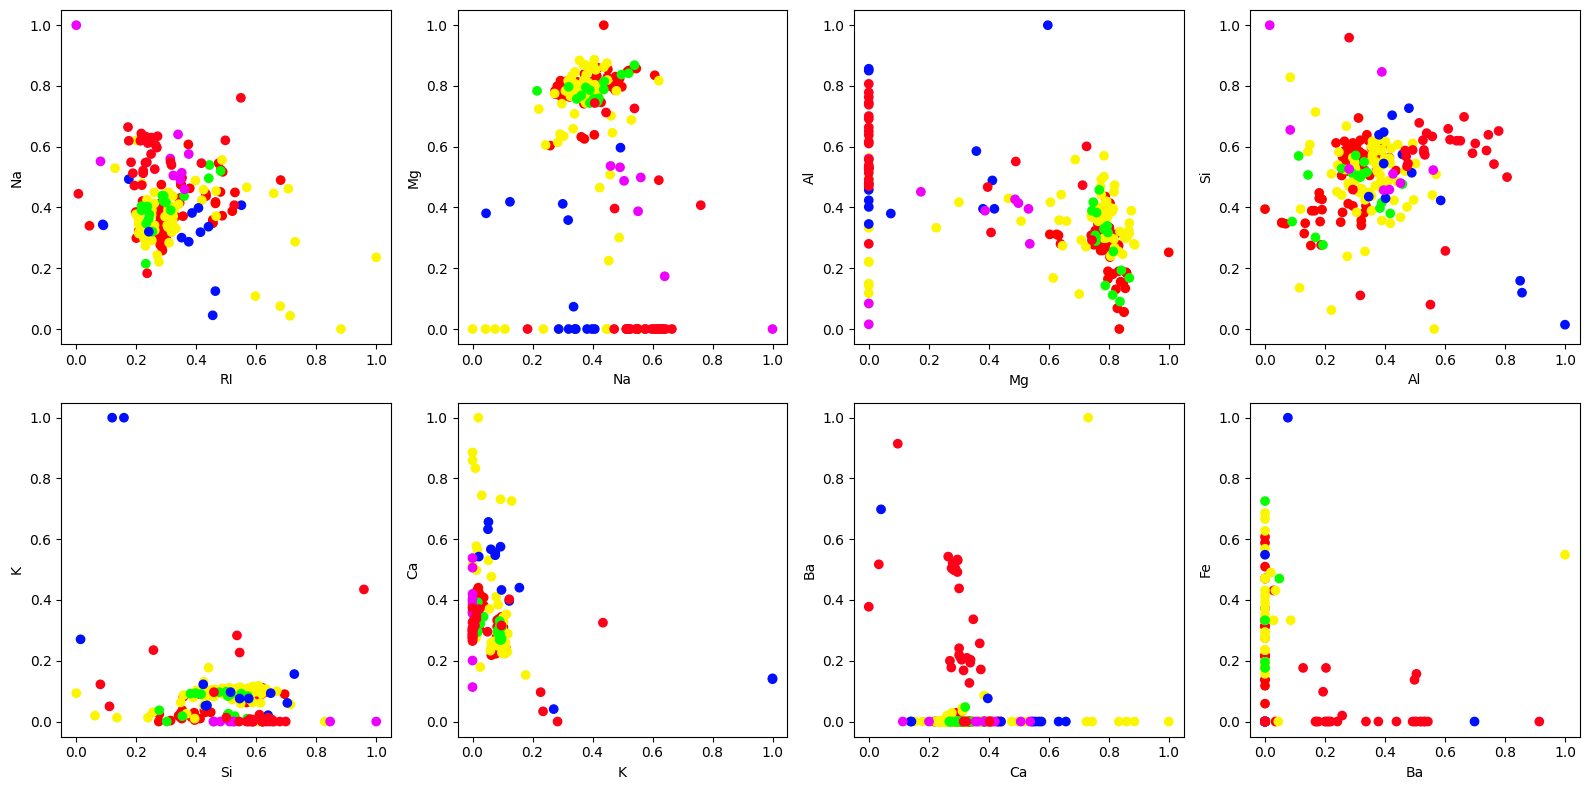

In [30]:
fig, axs = plt.subplots(2, 4)
fig.set_size_inches(16, 8)
for i in range(data.shape[1] - 1):
    axs[i // 4, i % 4].scatter(data[:, i], data[:, (i + 1)], c=labels, cmap='hsv')
    axs[i // 4, i % 4].set_xlabel(var_names[i])
    axs[i // 4, i % 4].set_ylabel(var_names[i + 1])
plt.tight_layout()
plt.show()

### Метод главных компонент

1. Понижение размерности до 2 с помощью PCA

In [31]:
pca = PCA(n_components=2)
pca_data = pca.fit(data).transform(data)

2. Вывод объясненной дисперсии и собственных чисел

In [32]:
print("\n=== PCA ===")
print(f"Объясненная дисперсия (доля): {pca.explained_variance_ratio_}")
print(f"Объясненная дисперсия (%): {pca.explained_variance_ratio_ * 100}")
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_) * 100:.2f}%")
print(f"Собственные числа (сингулярные значения): {pca.singular_values_}")


=== PCA ===
Объясненная дисперсия (доля): [0.45429569 0.17990097]
Объясненная дисперсия (%): [45.42956891 17.9900973 ]
Суммарная объясненная дисперсия: 63.42%
Собственные числа (сингулярные значения): [5.1049308  3.21245688]


3. Диаграмма рассеяния после PCA

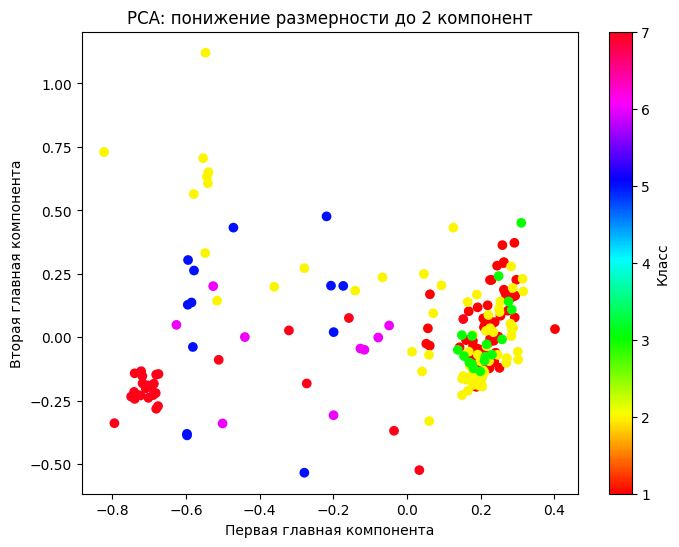

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap='hsv')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('PCA: понижение размерности до 2 компонент')
plt.colorbar(label='Класс')
plt.show()

4. Анализ результатов

In [34]:
print("\n=== Анализ результатов PCA ===")
print("Две главные компоненты объясняют суммарно около {:.2f}% дисперсии данных".format(
    sum(pca.explained_variance_ratio_) * 100))
print("Это позволяет визуализировать данные в 2D пространстве с минимальной потерей информации")
print("На диаграмме рассеяния видно, что классы частично разделимы")


=== Анализ результатов PCA ===
Две главные компоненты объясняют суммарно около 63.42% дисперсии данных
Это позволяет визуализировать данные в 2D пространстве с минимальной потерей информации
На диаграмме рассеяния видно, что классы частично разделимы


5. Определение количества компонент для 85% дисперсии

In [35]:
pca_full = PCA()
pca_full.fit(data)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_components_85 = np.argmax(cumsum >= 0.85) + 1
print(f"\nКоличество компонент для объяснения 85% дисперсии: {n_components_85}")
print(f"Кумулятивная дисперсия для {n_components_85} компонент: {cumsum[n_components_85-1]*100:.2f}%")


Количество компонент для объяснения 85% дисперсии: 4
Кумулятивная дисперсия для 4 компонент: 85.87%


# График кумулятивной дисперсии

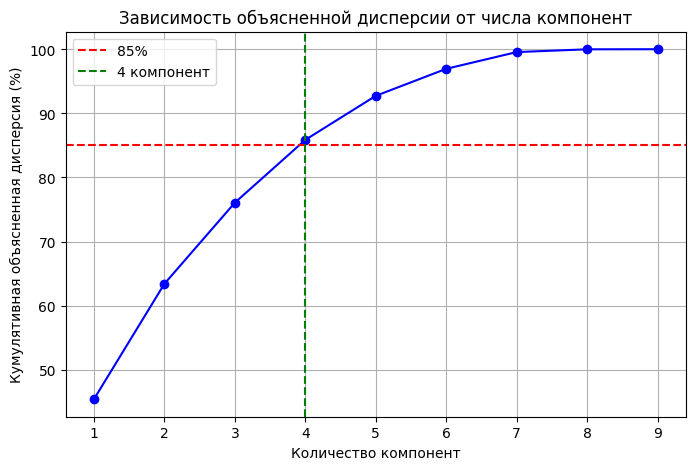

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumsum)+1), cumsum * 100, 'bo-')
plt.axhline(y=85, color='r', linestyle='--', label='85%')
plt.axvline(x=n_components_85, color='g', linestyle='--', label=f'{n_components_85} компонент')
plt.xlabel('Количество компонент')
plt.ylabel('Кумулятивная объясненная дисперсия (%)')
plt.title('Зависимость объясненной дисперсии от числа компонент')
plt.legend()
plt.grid()
plt.show()

6. Восстановление данных и сравнение

In [37]:
pca_inverse = PCA(n_components=2)
pca_inverse.fit(data)
data_reconstructed = pca_inverse.inverse_transform(pca_inverse.transform(data))
print("\n=== Сравнение исходных и восстановленных данных ===")
print(f"MSE восстановления: {np.mean((data - data_reconstructed)**2):.6f}")
print("При восстановлении теряется информация, соответствующая отброшенным компонентам")


=== Сравнение исходных и восстановленных данных ===
MSE восстановления: 0.010895
При восстановлении теряется информация, соответствующая отброшенным компонентам


7. Исследование различных параметров svd_solver

In [38]:
print("\n=== Исследование параметров svd_solver ===")
solvers = ['auto', 'full', 'arpack', 'randomized']
for solver in solvers:
    try:
        pca_test = PCA(n_components=2, svd_solver=solver)
        pca_test.fit(data)
        print(f"svd_solver={solver}: explained variance = {sum(pca_test.explained_variance_ratio_)*100:.2f}%")
    except Exception as e:
        print(f"svd_solver={solver}: ошибка - {e}")


=== Исследование параметров svd_solver ===
svd_solver=auto: explained variance = 63.42%
svd_solver=full: explained variance = 63.42%
svd_solver=arpack: explained variance = 63.42%
svd_solver=randomized: explained variance = 63.42%


### Модификации метода главных компонент

1. KernelPCA для различных параметров


=== KernelPCA ===
kernel=linear: форма данных после преобразования = (214, 2)


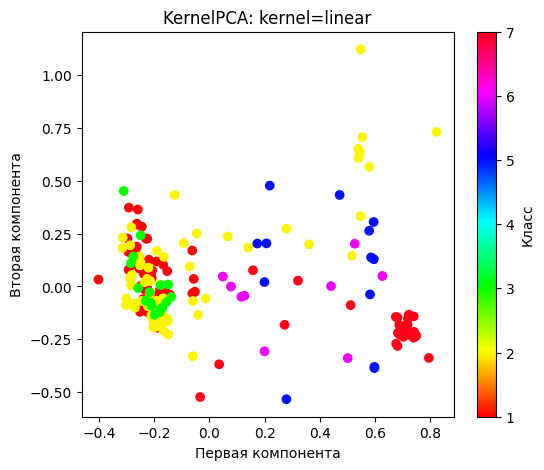

kernel=poly: форма данных после преобразования = (214, 2)


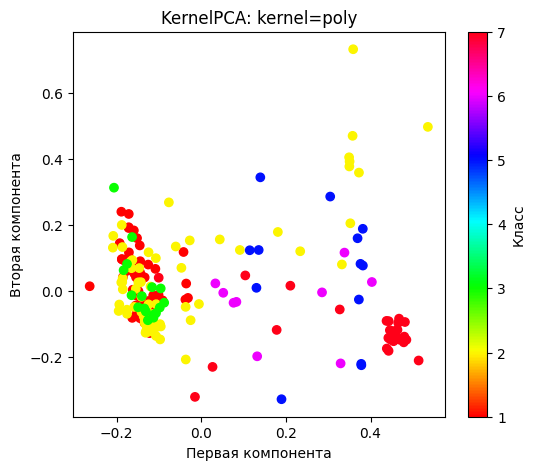

kernel=rbf: форма данных после преобразования = (214, 2)


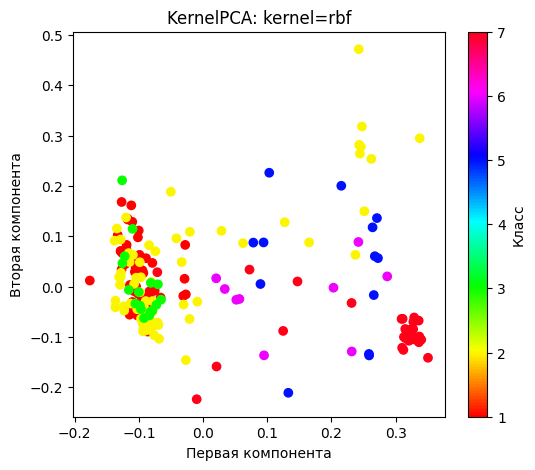

kernel=sigmoid: форма данных после преобразования = (214, 2)


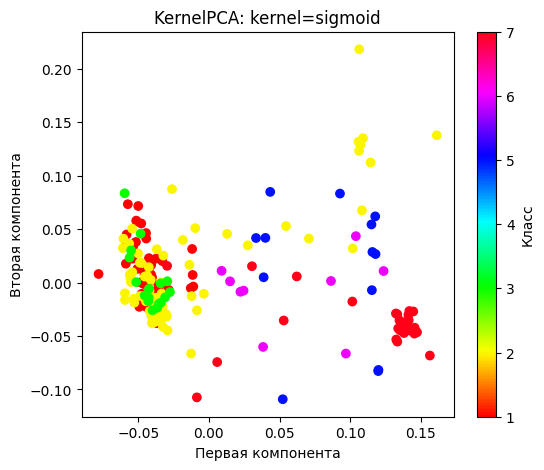

In [39]:
print("\n=== KernelPCA ===")
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    try:
        kpca = KernelPCA(n_components=2, kernel=kernel)
        kpca_data = kpca.fit_transform(data)
        print(f"kernel={kernel}: форма данных после преобразования = {kpca_data.shape}")

        # Визуализация для каждого ядра
        plt.figure(figsize=(6, 5))
        plt.scatter(kpca_data[:, 0], kpca_data[:, 1], c=labels, cmap='hsv')
        plt.xlabel('Первая компонента')
        plt.ylabel('Вторая компонента')
        plt.title(f'KernelPCA: kernel={kernel}')
        plt.colorbar(label='Класс')
        plt.show()
    except Exception as e:
        print(f"kernel={kernel}: ошибка - {e}")

2. KernelPCA с параметрами poly ядра


=== KernelPCA с различными параметрами для poly ядра ===
degree=2: объясненная дисперсия (приблизительно) = 0.4892


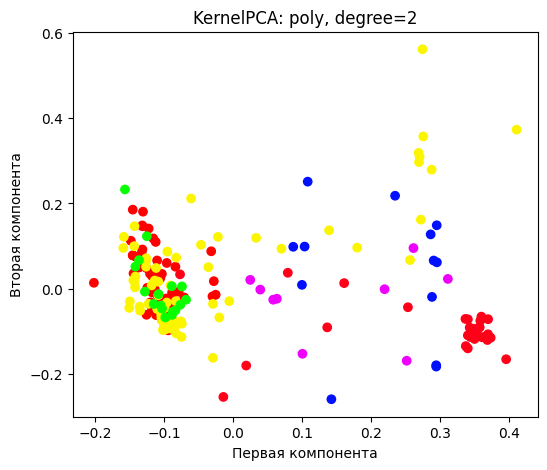

degree=3: объясненная дисперсия (приблизительно) = 0.8227


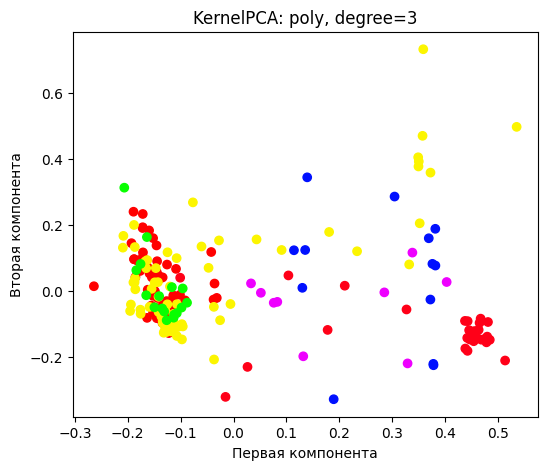

degree=4: объясненная дисперсия (приблизительно) = 1.2305


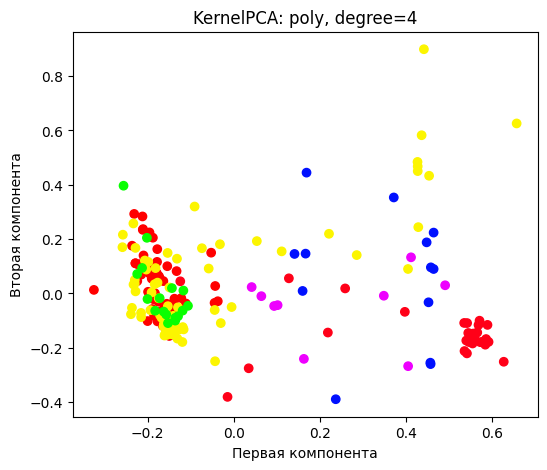

In [40]:
print("\n=== KernelPCA с различными параметрами для poly ядра ===")
degrees = [2, 3, 4]
for degree in degrees:
    kpca = KernelPCA(n_components=2, kernel='poly', degree=degree)
    kpca_data = kpca.fit_transform(data)
    print(f"degree={degree}: объясненная дисперсия (приблизительно) = {np.var(kpca_data[:,0])/np.var(data):.4f}")

    plt.figure(figsize=(6, 5))
    plt.scatter(kpca_data[:, 0], kpca_data[:, 1], c=labels, cmap='hsv')
    plt.xlabel('Первая компонента')
    plt.ylabel('Вторая компонента')
    plt.title(f'KernelPCA: poly, degree={degree}')
    plt.show()

Определение параметров, при которых KernelPCA работает как PCA

In [41]:
print("\n=== KernelPCA работает как PCA при kernel='linear' ===")
kpca_linear = KernelPCA(n_components=2, kernel='linear')
kpca_linear_data = kpca_linear.fit_transform(data)


=== KernelPCA работает как PCA при kernel='linear' ===


Сравнение с PCA

In [42]:
pca_comp = PCA(n_components=2)
pca_comp_data = pca_comp.fit_transform(data)
print("Корреляция между PCA и KernelPCA(linear):")
for i in range(2):
    corr = np.corrcoef(pca_comp_data[:, i], kpca_linear_data[:, i])[0, 1]
    print(f"  Компонента {i+1}: {corr:.6f}")

Корреляция между PCA и KernelPCA(linear):
  Компонента 1: -1.000000
  Компонента 2: 1.000000


3. SparsePCA


=== SparsePCA ===
Форма данных после SparsePCA: (214, 2)
Компоненты SparsePCA:
[[-0.06654491 -0.0714373   0.92832019 -0.20259079 -0.00954142  0.
  -0.17582718 -0.23799337  0.        ]
 [ 0.50469306 -0.19935608  0.         -0.36452857 -0.21230028 -0.09495474
   0.47606897 -0.16947597  0.51303938]]


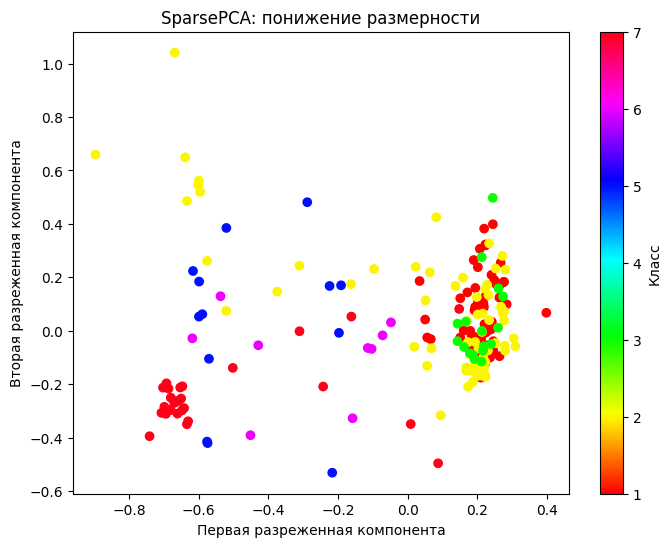

In [43]:
print("\n=== SparsePCA ===")
spca = SparsePCA(n_components=2, alpha=0.1)
spca_data = spca.fit_transform(data)
print(f"Форма данных после SparsePCA: {spca_data.shape}")
print(f"Компоненты SparsePCA:\n{spca.components_}")

plt.figure(figsize=(8, 6))
plt.scatter(spca_data[:, 0], spca_data[:, 1], c=labels, cmap='hsv')
plt.xlabel('Первая разреженная компонента')
plt.ylabel('Вторая разреженная компонента')
plt.title('SparsePCA: понижение размерности')
plt.colorbar(label='Класс')
plt.show()

Исследование различных alpha

In [44]:
print("\nИсследование параметра alpha:")
alphas = [0.01, 0.1, 0.5, 1.0]
for alpha in alphas:
    spca_test = SparsePCA(n_components=2, alpha=alpha, max_iter=100)
    spca_test_data = spca_test.fit_transform(data)
    n_nonzero = np.sum(spca_test.components_ != 0)
    print(f"alpha={alpha}: ненулевых элементов в компонентах = {n_nonzero}")


Исследование параметра alpha:
alpha=0.01: ненулевых элементов в компонентах = 18
alpha=0.1: ненулевых элементов в компонентах = 15
alpha=0.5: ненулевых элементов в компонентах = 6
alpha=1.0: ненулевых элементов в компонентах = 4


4. Анализ модификаций

1. PCA: линейное преобразование, максимизирующее дисперсию
2. KernelPCA: нелинейное преобразование, позволяет выделять нелинейные структуры
3. SparsePCA: создает разреженные компоненты, упрощая интерпретацию

### Факторный анализ

1. FactorAnalysis


=== Факторный анализ ===
Форма данных после FactorAnalysis: (214, 2)


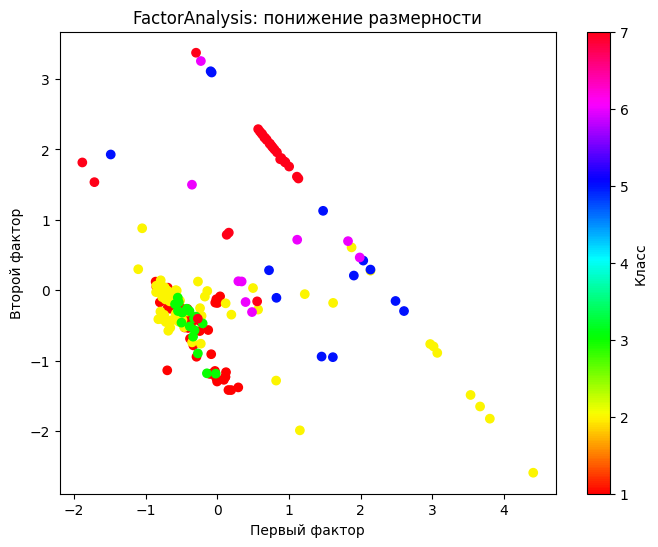

In [45]:
print("\n=== Факторный анализ ===")
fa = FactorAnalysis(n_components=2)
fa_data = fa.fit_transform(data)
print(f"Форма данных после FactorAnalysis: {fa_data.shape}")

plt.figure(figsize=(8, 6))
plt.scatter(fa_data[:, 0], fa_data[:, 1], c=labels, cmap='hsv')
plt.xlabel('Первый фактор')
plt.ylabel('Второй фактор')
plt.title('FactorAnalysis: понижение размерности')
plt.colorbar(label='Класс')
plt.show()

2. Сравнение с PCA

In [46]:
print("\n=== Сравнение FactorAnalysis и PCA ===")
print("PCA объясненная дисперсия:", pca.explained_variance_ratio_)
print("FactorAnalysis шумовая дисперсия:", fa.noise_variance_)
print("FactorAnalysis компоненты:\n", fa.components_)


=== Сравнение FactorAnalysis и PCA ===
PCA объясненная дисперсия: [0.45429569 0.17990097]
FactorAnalysis шумовая дисперсия: [4.79419841e-03 1.10022850e-02 4.46780951e-04 1.17145436e-02
 1.66313998e-02 9.62793885e-03 6.12563231e-05 1.54576552e-02
 3.48911687e-02]
FactorAnalysis компоненты:
 [[ 0.0822624  -0.00702332 -0.25166135  0.00813362 -0.009126   -0.02324994
   0.11894473  0.02528665  0.00884082]
 [-0.07827948  0.0629093  -0.19733579  0.11089294  0.04822956  0.02845741
  -0.05659645  0.0932882  -0.03691294]]


Корреляция между результатами

In [47]:
print("\nКорреляция между PCA и FactorAnalysis:")
for i in range(2):
    corr = np.corrcoef(pca_data[:, i], fa_data[:, i])[0, 1]
    print(f"  Компонента {i+1}: {corr:.6f}")


Корреляция между PCA и FactorAnalysis:
  Компонента 1: -0.732690
  Компонента 2: -0.654695


3. Объяснение различий

PCA (метод главных компонент):
- Ищет направления максимальной дисперсии
- Предполагает, что вся дисперсия является общей
- Компоненты ортогональны
- Результат - линейная комбинация исходных признаков

FactorAnalysis (факторный анализ):
- Моделирует ковариационную структуру данных
- Разделяет дисперсию на общую и уникальную (шум)
- Учитывает наличие специфической дисперсии
- Позволяет интерпретировать скрытые факторы

## Выводы

В ходе работы были изучены методы понижения размерности. PCA снизил размерность данных, сохранив основную дисперсию. KernelPCA позволил выполнить нелинейное преобразование, SparsePCA создал разреженные компоненты. Факторный анализ, в отличие от PCA, учитывает наличие шума и разделяет дисперсию на общую и уникальную.